<!-- @format -->

# 03 - Baseline Models

Notebook này huấn luyện và so sánh 2 mô hình baseline: **Linear Regression** và **Decision Tree**.

**Dữ liệu đầu vào:** `X_train.csv`, `X_test.csv`, `y_train.csv`, `y_test.csv`.


<!-- @format -->

## 1. Setup & Load Data


In [1]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

project_root = Path("..").resolve()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.config import (
    X_TRAIN_FILE, X_TEST_FILE, Y_TRAIN_FILE, Y_TEST_FILE,
    TARGET_COL, RANDOM_STATE, MODELS_DIR
)
from src.utils import save_model

sns.set_theme(style="whitegrid")
print("Setup OK")

Setup OK


In [2]:
# Đọc dữ liệu đã tách sẵn
X_train = pd.read_csv(X_TRAIN_FILE)
X_test = pd.read_csv(X_TEST_FILE)
y_train = pd.read_csv(Y_TRAIN_FILE)[TARGET_COL]
y_test = pd.read_csv(Y_TEST_FILE)[TARGET_COL]

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}, y_test: {y_test.shape}")
print(f"\nCác cột features ({X_train.shape[1]}):")
print(list(X_train.columns))

X_train: (8369, 17), X_test: (2093, 17)
y_train: (8369,), y_test: (2093,)

Các cột features (17):
['Airline_0', 'Airline_1', 'Airline_2', 'Airline_3', 'Source_0', 'Source_1', 'Source_2', 'Destination_0', 'Destination_1', 'Destination_2', 'journey_day', 'journey_month', 'day_of_week', 'dep_hour', 'arrival_hour', 'duration_minutes', 'total_stops_num']


<!-- @format -->

## 2. Hàm đánh giá chung

Mỗi model sẽ được đánh giá bằng 3 chỉ số:

- **MAE** (Mean Absolute Error): Sai số tuyệt đối trung bình
- **RMSE** (Root Mean Squared Error): Sai số bình phương trung bình gốc
- **R²** (Coefficient of Determination): Mức độ giải thích của mô hình (càng gần 1 càng tốt)


In [3]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    """Train model, dự đoán và tính metrics."""
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model", model),
    ])
    pipe.fit(X_tr, y_tr)
    y_pred = pipe.predict(X_te)
    
    mae = mean_absolute_error(y_te, y_pred)
    rmse = mean_squared_error(y_te, y_pred) ** 0.5
    r2 = r2_score(y_te, y_pred)
    
    print(f"{'='*40}")
    print(f"Model: {name}")
    print(f"  MAE  = {mae:,.2f}")
    print(f"  RMSE = {rmse:,.2f}")
    print(f"  R²   = {r2:.4f}")
    
    return pipe, {"model": name, "MAE": round(mae, 2), "RMSE": round(rmse, 2), "R2": round(r2, 4)}

<!-- @format -->

## 3. Train Linear Regression

Mô hình đơn giản nhất - tìm quan hệ tuyến tính giữa các features và giá vé.


In [4]:
results = []

lr_model = LinearRegression()
lr_pipe, lr_metrics = evaluate_model("Linear Regression", lr_model, X_train, y_train, X_test, y_test)
results.append(lr_metrics)

Model: Linear Regression
  MAE  = 1,804.90
  RMSE = 2,302.48
  R²   = 0.6198


<!-- @format -->

## 4. Train Decision Tree

Mô hình cây quyết định - chia dữ liệu theo các điều kiện trên features để dự đoán giá vé. Đây là nền tảng cho các mô hình ensemble như Random Forest.


In [5]:
dt_model = DecisionTreeRegressor(random_state=RANDOM_STATE)
dt_pipe, dt_metrics = evaluate_model("Decision Tree", dt_model, X_train, y_train, X_test, y_test)
results.append(dt_metrics)

Model: Decision Tree
  MAE  = 1,076.84
  RMSE = 1,739.16
  R²   = 0.7831


<!-- @format -->

## 5. So sánh Baseline Models


,model,MAE,RMSE,R2
1,Decision Tree,1076.84,1739.16,0.7831
0,Linear Regression,1804.90,2302.48,0.6198


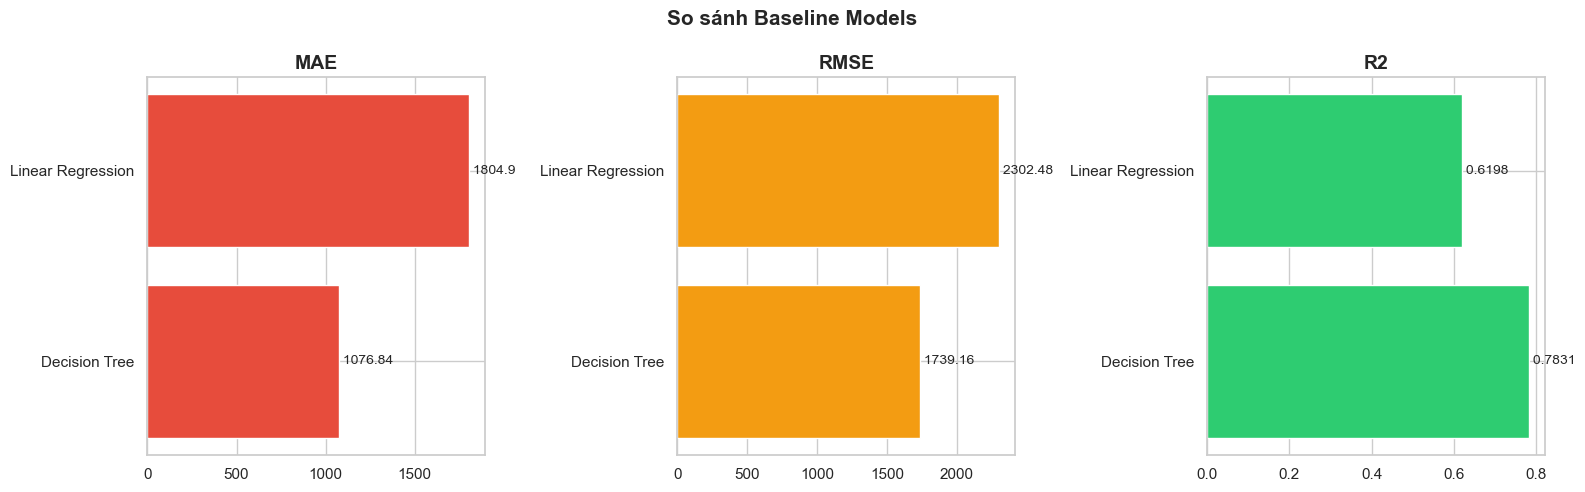

In [6]:
# Bảng so sánh
results_df = pd.DataFrame(results).sort_values("R2", ascending=False)
display(results_df)

# Biểu đồ so sánh
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics_list = ["MAE", "RMSE", "R2"]
colors = ["#e74c3c", "#f39c12", "#2ecc71"]

for ax, metric, color in zip(axes, metrics_list, colors):
    df_sorted = results_df.sort_values(metric, ascending=(metric != "R2"))
    ax.barh(df_sorted["model"], df_sorted[metric], color=color, edgecolor="white")
    ax.set_title(metric, fontsize=14, fontweight="bold")
    for i, v in enumerate(df_sorted[metric]):
        ax.text(v, i, f" {v}", va="center", fontsize=10)

plt.suptitle("So sánh Baseline Models", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

<!-- @format -->

## 6. Lưu mô hình Baseline


In [7]:
models_to_save = {
    "linear_regression": lr_pipe,
    "decision_tree": dt_pipe,
}
for name, pipe in models_to_save.items():
    path = MODELS_DIR / "baseline" / f"{name}.joblib"
    save_model(pipe, path)
    print(f"Saved: {path}")

Saved: D:\Data_Mining\DataMining-FlightPricePrediction\models\baseline\linear_regression.joblib
Saved: D:\Data_Mining\DataMining-FlightPricePrediction\models\baseline\decision_tree.joblib


<!-- @format -->

## Nhận xét

- **Decision Tree** cho kết quả tốt hơn Linear Regression nhờ khả năng nắm bắt quan hệ **phi tuyến** giữa features và giá vé.
- **Linear Regression** hạn chế vì giả định quan hệ tuyến tính, không phù hợp với dữ liệu có tương tác phức tạp.
- Decision Tree dễ bị **overfitting** do học quá chi tiết trên tập train → cần cải tiến bằng mô hình ensemble.

**Bước tiếp theo:** Notebook 03b sẽ sử dụng **Random Forest** (ensemble của nhiều Decision Tree) để cải thiện kết quả.
